<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Lane_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

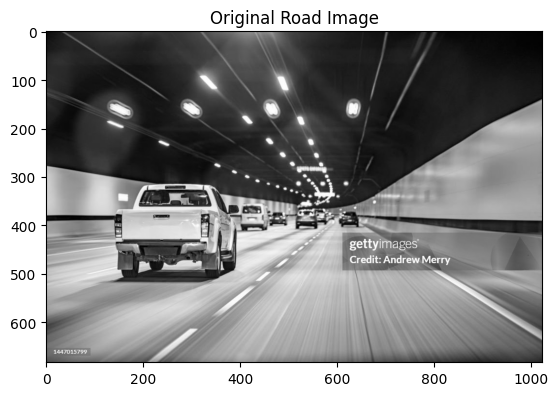

In [4]:
img = cv2.imread("highway.jpg")            # replace with dataset image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(cv2.cvtColor(gray, cv2.COLOR_BGR2RGB))
plt.title("Original Road Image")
plt.show()

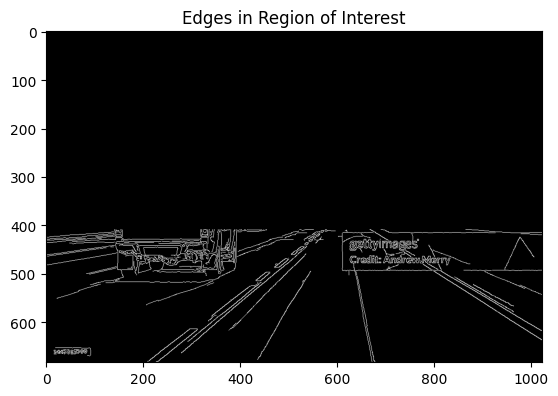

In [5]:
edges = cv2.Canny(gray, 50, 150)

# Define region of interest (ROI)
height, width = edges.shape
mask = np.zeros_like(edges)
polygon = np.array([[
    (0, height),
    (width, height),
    (width, int(height*0.6)),
    (0, int(height*0.6))
]])
cv2.fillPoly(mask, polygon, 255)
masked = cv2.bitwise_and(edges, mask)

plt.imshow(masked, cmap='gray')
plt.title("Edges in Region of Interest")
plt.show()


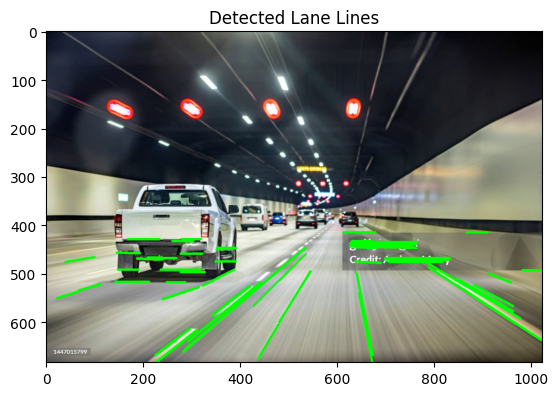

In [6]:
lines = cv2.HoughLinesP(masked, 2, np.pi/180, 100,
                        np.array([]), minLineLength=40, maxLineGap=5)

line_img = np.copy(img)
for line in lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(line_img, (x1, y1), (x2, y2), (0, 255, 0), 3)

plt.imshow(cv2.cvtColor(line_img, cv2.COLOR_BGR2RGB))
plt.title("Detected Lane Lines")
plt.show()
